In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from utils.data_loader import DataLoader

bin C:\Users\ljh\AppData\Roaming\Python\Python310\site-packages\bitsandbytes\libbitsandbytes_cuda116.dll


In [2]:
dataloader = DataLoader()

In [3]:
dataset = dataloader.load_data('G:\Research\数据集\Pper4-Database\Spectral Database',type='text')

100%|██████████| 306/306 [00:02<00:00, 120.66it/s]


In [4]:
dataset['1']

{'Path': 'G:\\Research\\数据集\\Pper4-Database\\Spectral Database\\(C5F9)2\\[0]Perfluorodecalin (cis), HITRAN (x-sec), X=0.01, T=300.0 K, P=0.0 atm, L=15 cm.csv',
 'Name': '[0]Perfluorodecalin (cis), HITRAN (x-sec), X=0.01, T=300.0 K, P=0.0 atm, L=15 cm.csv',
 'Data':                 nu  \
 0       560.000000   
 1       560.060265   
 2       560.120530   
 3       560.180795   
 4       560.241060   
 ...            ...   
 40483  2999.707995   
 40484  2999.768260   
 40485  2999.828525   
 40486  2999.888790   
 40487  2999.949055   
 
        [0]Perfluorodecalin(cis)-HITRAN(x-sec)-X=0.01-T=300.0K-P=0.0atm-L=15cm  
 0                                                    1.0                       
 1                                                    1.0                       
 2                                                    1.0                       
 3                                                    1.0                       
 4                                                  

读取分子式和学名

In [11]:
# 先取出所有的名字
Fenzishi = []
Mingzi = []
for key,value in dataset.items():
    fenzishi = value['Path'].split('\\')[-2]
    mingzi = value['Name'].split(',')[0]
    Fenzishi.append(fenzishi)
    Mingzi.append(mingzi)

In [13]:
# 创建一个DataFrame，具有三列，列名分别为：Molecular formula, Name, Class。前两列分别由Fenzishi和Mingzi填充，最后一列填充空值
df = pd.DataFrame(columns=['Molecular formula', 'Name', 'Class'])
df['Molecular formula'] = Fenzishi
df['Name'] = Mingzi
df['Class'] = np.nan
df


,Molecular formula,Name,Class
0,(C5F9)2,[0]Perfluorodecalin (cis),NaN
1,(C6H4)2,[0]Naphthalene,NaN
2,(CBrF2)2,[0]Halon-2402,NaN
3,(CCI2F)2,[0]CFC-112,NaN
4,(CF2)4,[0]PFC-318,NaN
...,...,...,...
301,S=O(CH3)2,[0]Dimethyl sulfoxide,NaN
302,SF5CF3,[0]Trifluoromethyl sulfur pentafluoride,NaN
303,SiH4,[0]Silane,NaN
304,trans-CF3CH=CHCI,[0]HCFO-1233zd,NaN


In [14]:
# 保存df为xlsx
df.to_excel('G:\Research\数据集\Pper4-Database\Spect-plot_record.xlsx',index=False)

光谱图

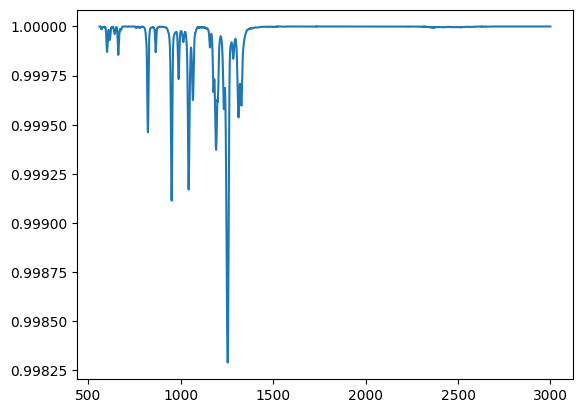

In [13]:
#dataset['1']['Data']
# 将dataset['1']['Data']数据画出来，要求以第一列为横坐标，第二列为纵坐标
plt.plot(dataset['1']['Data'].iloc[:,0],dataset['1']['Data'].iloc[:,1])


In [17]:
# 读取xlsx文件
dataaa = pd.read_excel('G:\Research\数据集\Pper4-Database\Spect-plot_record.xlsx')

In [21]:
# 在dataaa的Name列中，如果某个单元格的值中包含“[0]”，则在字符串中删除“[0]”
for i in range(len(dataaa)):
    if '[0]' in dataaa['Name'][i]:
        dataaa['Name'][i] = dataaa['Name'][i].replace('[0]','')

C:\Users\ljh\AppData\Local\Temp\ipykernel_27900\251767707.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dataaa['Name'][i] = dataaa['Name'][i].replace('[0]','')
C:\Users\ljh\AppData\Local\Temp\ipykernel_27900\251767707.py:4: SettingWith

In [23]:
dataaa.to_excel('G:\Research\数据集\Pper4-Database\Spect-plot_record22.xlsx',index=False)